In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})

fig_dir = Path("../figures/model_comparison")
fig_dir.mkdir(parents=True, exist_ok=True)

test_path = "../.data/downscaling_splits/test_norm.nc"

# Change this if your file is singular: "../outputs/test_prediction.nc"
unet_path = "../outputs/test_predictions.nc"
transformer_path = "../outputs/test_predictions_transformer_t_elev_oscar.nc"

ds_test = xr.open_dataset(test_path)
ds_unet = xr.open_dataset(unet_path)
ds_tf = xr.open_dataset(transformer_path)

print(ds_test)
print(ds_unet)
print(ds_tf)


<xarray.Dataset> Size: 552MB
Dimensions:             (time: 368, lat_coarse: 39, lon_coarse: 51, lat: 240,
                         lon: 311)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2022-06-01 ... 2025-08-31
  * lat_coarse          (lat_coarse) float64 312B 46.75 46.5 ... 37.5 37.25
  * lon_coarse          (lon_coarse) float64 408B -79.75 -79.5 ... -67.5 -67.25
  * lat                 (lat) float64 2kB 46.98 46.94 46.9 ... 37.11 37.07 37.03
  * lon                 (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.1 -67.06
Data variables:
    tmax_lowres         (time, lat_coarse, lon_coarse) float32 3MB ...
    tmax_highres        (time, lat, lon) float32 110MB ...
    valid_mask          (lat, lon) int8 75kB ...
    tmax_lowres_interp  (time, lat, lon) float32 110MB ...
    tmax_residual       (time, lat, lon) float32 110MB ...
    x_norm              (time, lat, lon) float32 110MB ...
    y_norm              (time, lat, lon) float32 110MB ...
Attributes:
    descr

In [15]:
# Convert absolute temperature fields from K to deg C.
# Error metrics such as RMSE/MAE have the same numeric size in K and deg C,
# but labels should be deg C.
def kelvin_to_celsius_if_needed(da):
    if float(da.where(mask).mean(skipna=True)) > 100:
        return da - 273.15
    return da

truth = kelvin_to_celsius_if_needed(truth)
interp = kelvin_to_celsius_if_needed(interp)
unet = kelvin_to_celsius_if_needed(unet)
tf = kelvin_to_celsius_if_needed(tf)


In [2]:
# Variable names based on your existing plotting notebooks
pred_var = "pred_tmax_highres"
truth_var = "tmax_highres"
interp_var = "tmax_lowres_interp"
mask_var = "valid_mask"

# Use only times available in both prediction files and test set
common_time = np.intersect1d(ds_unet["time"].values, ds_tf["time"].values)
common_time = np.intersect1d(common_time, ds_test["time"].values)

truth = ds_test[truth_var].sel(time=common_time)
interp = ds_test[interp_var].sel(time=common_time)
unet = ds_unet[pred_var].sel(time=common_time)
tf = ds_tf[pred_var].sel(time=common_time)

mask = ds_test[mask_var].astype(bool)

print("truth:", truth.shape)
print("interp:", interp.shape)
print("unet:", unet.shape)
print("transformer:", tf.shape)


truth: (368, 240, 311)
interp: (368, 240, 311)
unet: (368, 240, 311)
transformer: (368, 240, 311)


In [3]:
def masked_values(da, mask):
    return da.where(mask).values

def overall_metrics(pred, truth, mask):
    err = pred.where(mask) - truth.where(mask)
    pred_m = pred.where(mask)
    truth_m = truth.where(mask)

    x = pred_m.values.ravel()
    y = truth_m.values.ravel()
    valid = np.isfinite(x) & np.isfinite(y)

    mse = np.nanmean(err.values ** 2)
    rmse = np.sqrt(mse)
    mae = np.nanmean(np.abs(err.values))
    bias = np.nanmean(err.values)
    corr = np.corrcoef(x[valid], y[valid])[0, 1]

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "Overall correlation": corr,
    }

def daily_rmse(pred, truth, mask):
    err2 = ((pred - truth) ** 2).where(mask)
    return np.sqrt(err2.mean(dim=("lat", "lon"), skipna=True))

def daily_mae(pred, truth, mask):
    err = np.abs(pred - truth).where(mask)
    return err.mean(dim=("lat", "lon"), skipna=True)

def daily_spatial_corr(pred, truth, mask):
    mask2d = mask.values.astype(bool)
    corrs = []

    for i in range(truth.sizes["time"]):
        x = pred.isel(time=i).values
        y = truth.isel(time=i).values
        valid = mask2d & np.isfinite(x) & np.isfinite(y)

        if valid.sum() < 2 or np.std(x[valid]) == 0 or np.std(y[valid]) == 0:
            corrs.append(np.nan)
        else:
            corrs.append(np.corrcoef(x[valid], y[valid])[0, 1])

    return xr.DataArray(corrs, coords={"time": truth["time"]}, dims=("time",))

def daily_std_ratio(pred, truth, mask):
    mask2d = mask.values.astype(bool)
    ratios = []

    for i in range(truth.sizes["time"]):
        x = pred.isel(time=i).values
        y = truth.isel(time=i).values
        valid = mask2d & np.isfinite(x) & np.isfinite(y)

        if valid.sum() < 2 or np.std(y[valid]) == 0:
            ratios.append(np.nan)
        else:
            ratios.append(np.std(x[valid]) / np.std(y[valid]))

    return xr.DataArray(ratios, coords={"time": truth["time"]}, dims=("time",))


In [4]:
models = {
    "Interpolation": interp,
    "U-Net T+Elev": unet,
    "Transformer T+Elev": tf,
}

summary = pd.DataFrame({
    name: overall_metrics(pred, truth, mask)
    for name, pred in models.items()
}).T

summary["RMSE improvement vs interp (%)"] = (
    (summary.loc["Interpolation", "RMSE"] - summary["RMSE"])
    / summary.loc["Interpolation", "RMSE"] * 100
)

summary["MAE improvement vs interp (%)"] = (
    (summary.loc["Interpolation", "MAE"] - summary["MAE"])
    / summary.loc["Interpolation", "MAE"] * 100
)

summary


,MSE,RMSE,MAE,Bias,Overall correlation,RMSE improvement vs interp (%),MAE improvement vs interp (%)
Interpolation,2.461787,1.569008,1.193424,-0.513263,0.941367,0.000000,0.000000
U-Net T+Elev,1.368507,1.169832,0.902376,-0.078094,0.963428,25.441302,24.387611
Transformer T+Elev,1.333456,1.154754,0.884036,-0.120808,0.965489,26.402318,25.924365


In [5]:
daily = pd.DataFrame(index=pd.to_datetime(common_time))

for name, pred in models.items():
    daily[f"{name} RMSE"] = daily_rmse(pred, truth, mask).values
    daily[f"{name} MAE"] = daily_mae(pred, truth, mask).values
    daily[f"{name} Spatial corr"] = daily_spatial_corr(pred, truth, mask).values
    daily[f"{name} Std ratio"] = daily_std_ratio(pred, truth, mask).values

daily.head()


,Interpolation RMSE,Interpolation MAE,Interpolation Spatial corr,Interpolation Std ratio,U-Net T+Elev RMSE,U-Net T+Elev MAE,U-Net T+Elev Spatial corr,U-Net T+Elev Std ratio,Transformer T+Elev RMSE,Transformer T+Elev MAE,Transformer T+Elev Spatial corr,Transformer T+Elev Std ratio
2022-06-01,1.974516,1.570240,0.959668,0.938276,1.854987,1.484120,0.959339,0.896022,1.949048,1.598804,0.958298,0.858232
2022-06-02,1.815732,1.392966,0.946260,1.103640,1.114243,0.877365,0.971136,1.057371,1.091479,0.854025,0.970387,1.012842
2022-06-03,1.660647,1.358530,0.907457,0.982836,1.436130,1.105063,0.912903,0.952429,1.348085,1.042498,0.923482,0.902229
2022-06-04,1.554300,1.199718,0.928666,1.035364,0.971134,0.773734,0.964228,1.001384,0.970089,0.771103,0.963872,0.945666
2022-06-05,1.599296,1.266139,0.910486,1.197231,1.090893,0.863493,0.951932,1.208865,0.948994,0.748003,0.955973,1.127049


In [6]:
# Poster/table summary of daily behavior
daily_summary = daily.agg(["mean", "median", "std"]).T
daily_summary


,mean,median,std
Interpolation RMSE,1.552490,1.539494,0.227375
Interpolation MAE,1.193424,1.181202,0.175865
Interpolation Spatial corr,0.847681,0.870074,0.094858
Interpolation Std ratio,1.052031,1.041882,0.120571
U-Net T+Elev RMSE,1.134664,1.087896,0.285078
U-Net T+Elev MAE,0.902376,0.867787,0.226560
U-Net T+Elev Spatial corr,0.914796,0.932731,0.058348
U-Net T+Elev Std ratio,0.969884,0.972296,0.103668
Transformer T+Elev RMSE,1.115092,1.058469,0.300451
Transformer T+Elev MAE,0.884036,0.842167,0.239048


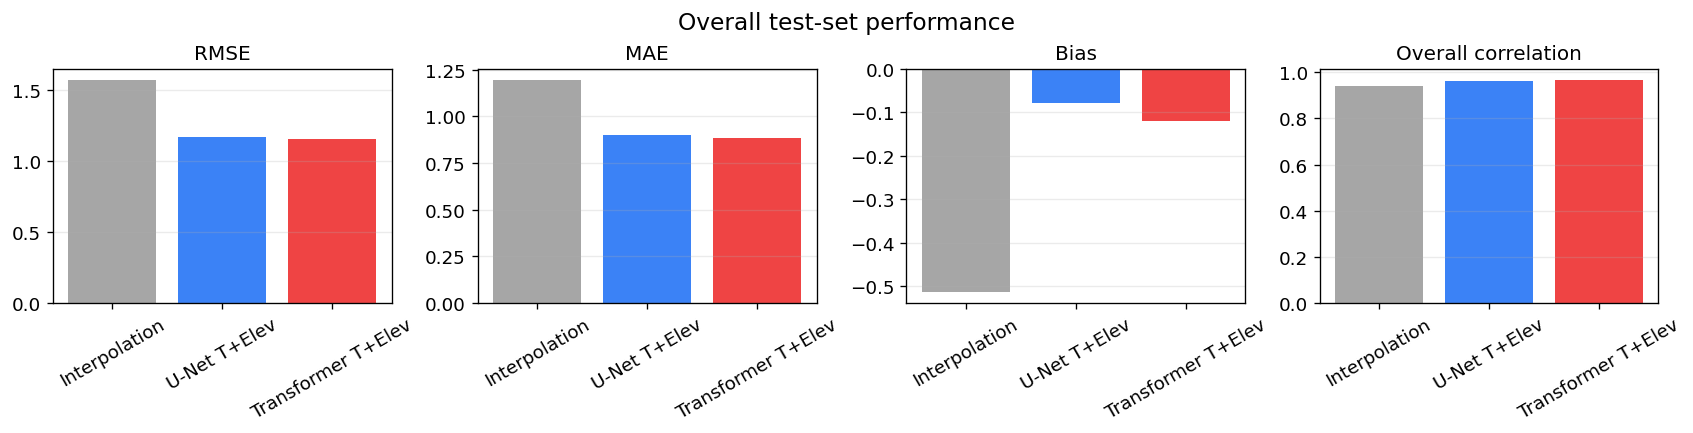

In [7]:
# Bar plot of overall metrics
plot_metrics = ["RMSE", "MAE", "Bias", "Overall correlation"]

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(14, 3.5), constrained_layout=True)

for ax, metric in zip(axes, plot_metrics):
    vals = summary[metric]
    colors = ["0.65", "#3B82F6", "#EF4444"]
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Overall test-set performance", fontsize=14)
plt.savefig(fig_dir / "overall_metrics_bar.png", bbox_inches="tight", dpi=300)
plt.show()


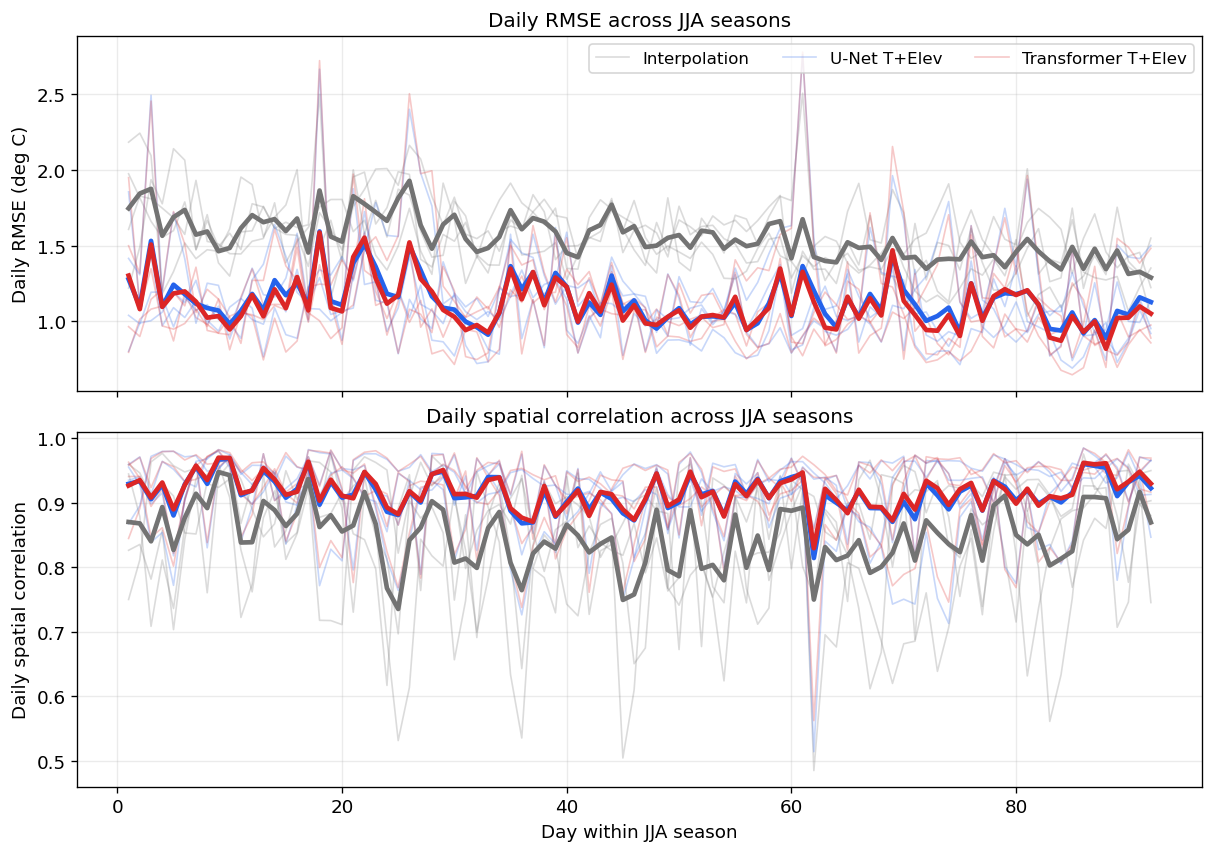

In [16]:
# Daily RMSE and daily spatial correlation, split by year so JJA seasons are not connected across years
daily_plot = daily.copy()
daily_plot["year"] = daily_plot.index.year
daily_plot["jja_day"] = daily_plot.index.dayofyear - daily_plot.groupby(daily_plot.index.year).cumcount().groupby(daily_plot.index.year).transform("min")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

colors = {
    "Interpolation": "0.45",
    "U-Net T+Elev": "#2563EB",
    "Transformer T+Elev": "#DC2626",
}

for year, df_year in daily_plot.groupby("year"):
    x = np.arange(1, len(df_year) + 1)

    for name in models:
        label = name if year == daily_plot["year"].min() else None
        axes[0].plot(
            x, df_year[f"{name} RMSE"],
            color=colors[name], alpha=0.25, linewidth=1.0, label=label
        )
        axes[1].plot(
            x, df_year[f"{name} Spatial corr"],
            color=colors[name], alpha=0.25, linewidth=1.0, label=label
        )

# Add across-year mean seasonal cycle
for name in models:
    grouped = daily_plot.groupby(daily_plot.groupby("year").cumcount() + 1)

    mean_rmse = grouped[f"{name} RMSE"].mean()
    mean_corr = grouped[f"{name} Spatial corr"].mean()

    axes[0].plot(
        mean_rmse.index, mean_rmse.values,
        color=colors[name], linewidth=2.8
    )
    axes[1].plot(
        mean_corr.index, mean_corr.values,
        color=colors[name], linewidth=2.8
    )

axes[0].set_ylabel("Daily RMSE (deg C)")
axes[0].set_title("Daily RMSE across JJA seasons")
axes[0].grid(alpha=0.25)
axes[0].legend(ncol=3)

axes[1].set_ylabel("Daily spatial correlation")
axes[1].set_xlabel("Day within JJA season")
axes[1].set_title("Daily spatial correlation across JJA seasons")
axes[1].grid(alpha=0.25)

plt.savefig(fig_dir / "daily_rmse_spatial_corr_jja.png", bbox_inches="tight", dpi=300)
plt.show()


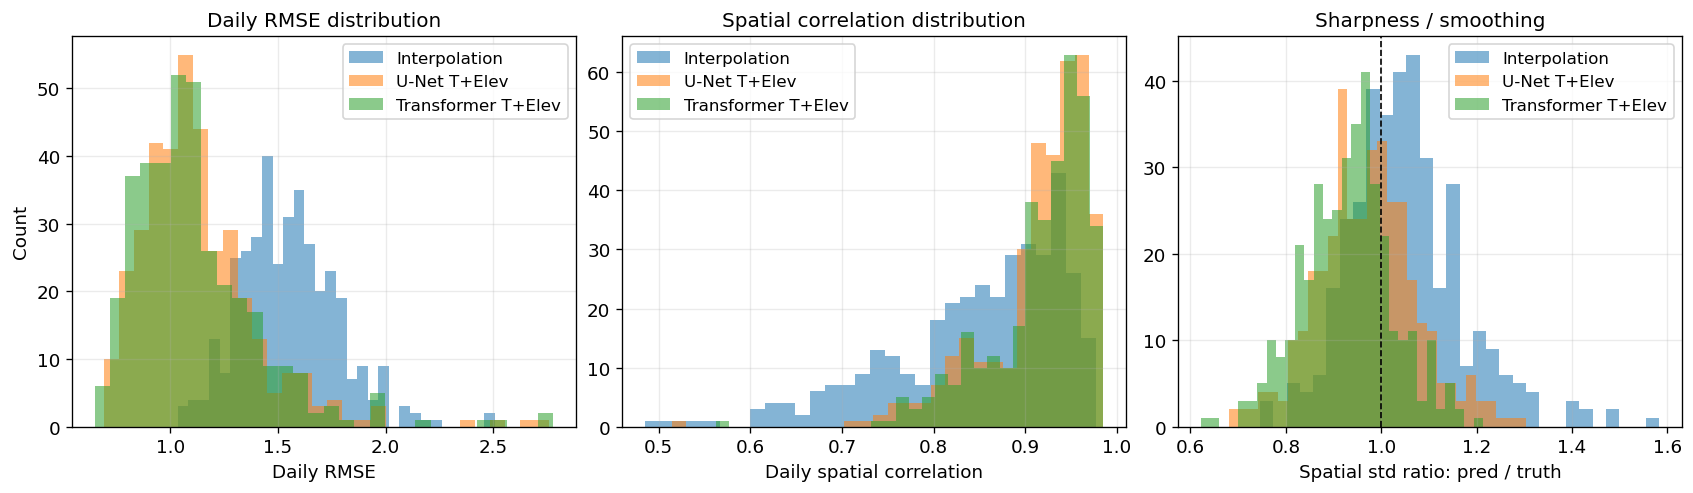

In [9]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for name in models:
    axes[0].hist(daily[f"{name} RMSE"], bins=30, alpha=0.55, label=name)
axes[0].set_xlabel("Daily RMSE")
axes[0].set_ylabel("Count")
axes[0].set_title("Daily RMSE distribution")

for name in models:
    axes[1].hist(daily[f"{name} Spatial corr"], bins=30, alpha=0.55, label=name)
axes[1].set_xlabel("Daily spatial correlation")
axes[1].set_title("Spatial correlation distribution")

for name in models:
    axes[2].hist(daily[f"{name} Std ratio"], bins=30, alpha=0.55, label=name)
axes[2].axvline(1, color="k", linestyle="--", linewidth=1)
axes[2].set_xlabel("Spatial std ratio: pred / truth")
axes[2].set_title("Sharpness / smoothing")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()

plt.savefig(fig_dir / "daily_metric_distributions.png", bbox_inches="tight", dpi=300)
plt.show()


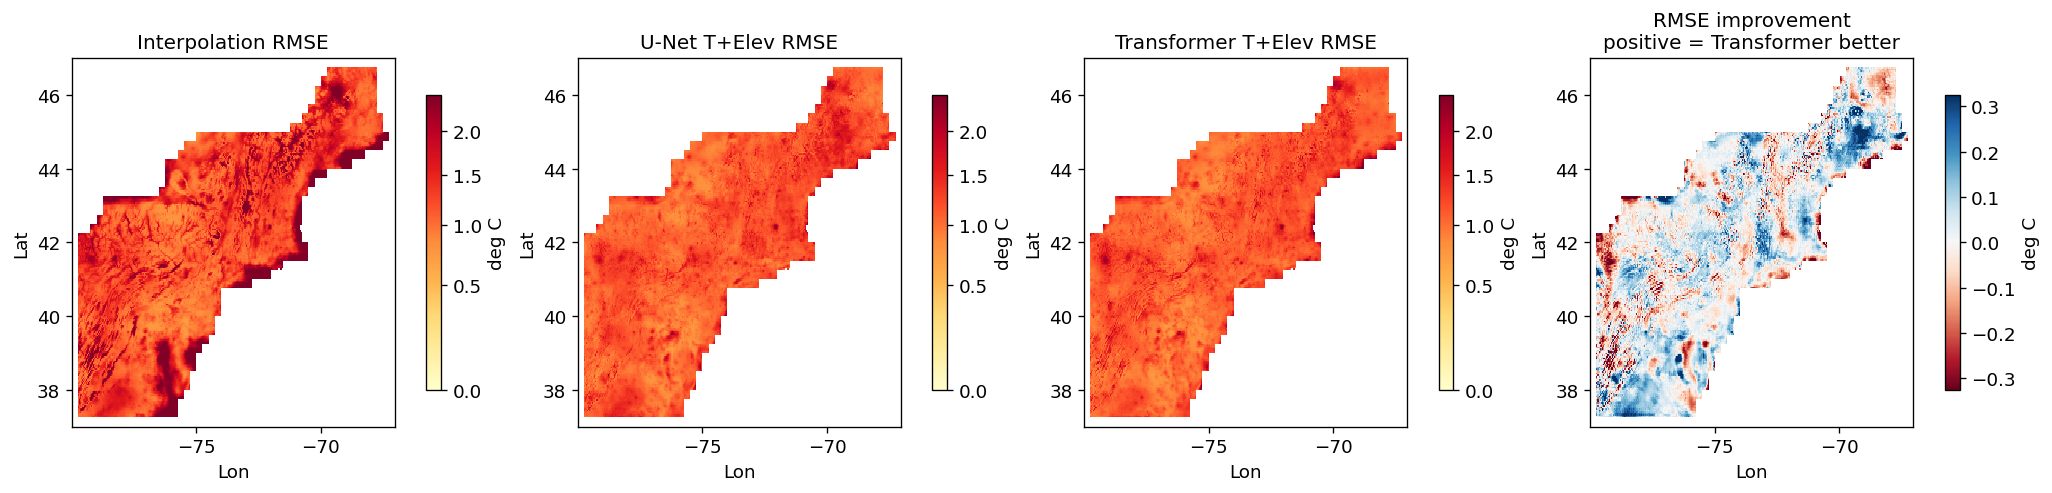

In [17]:
from matplotlib.colors import PowerNorm

# Spatial RMSE maps
def spatial_rmse(pred, truth, mask):
    return np.sqrt(((pred - truth) ** 2).where(mask).mean(dim="time", skipna=True))

rmse_interp = spatial_rmse(interp, truth, mask)
rmse_unet = spatial_rmse(unet, truth, mask)
rmse_tf = spatial_rmse(tf, truth, mask)

# Positive means Transformer has lower RMSE than U-Net
rmse_improve_tf_vs_unet = rmse_unet - rmse_tf

# Robust upper limit avoids one or two high-error pixels washing out the map
vmax = np.nanpercentile(
    np.concatenate([
        rmse_interp.where(mask).values.ravel(),
        rmse_unet.where(mask).values.ravel(),
        rmse_tf.where(mask).values.ravel(),
    ]),
    98
)

diff_max = np.nanpercentile(np.abs(rmse_improve_tf_vs_unet.where(mask).values), 98)

fig, axes = plt.subplots(1, 4, figsize=(17, 4), constrained_layout=True)

panels = [
    (rmse_interp, "Interpolation RMSE", "YlOrRd", 0, vmax, PowerNorm(gamma=0.65, vmin=0, vmax=vmax)),
    (rmse_unet, "U-Net T+Elev RMSE", "YlOrRd", 0, vmax, PowerNorm(gamma=0.65, vmin=0, vmax=vmax)),
    (rmse_tf, "Transformer T+Elev RMSE", "YlOrRd", 0, vmax, PowerNorm(gamma=0.65, vmin=0, vmax=vmax)),
    (rmse_improve_tf_vs_unet, "RMSE improvement\npositive = Transformer better", "RdBu", -diff_max, diff_max, None),
]

for ax, (da, title, cmap, vmin, vmax_, norm) in zip(axes, panels):
    if norm is None:
        pcm = ax.pcolormesh(
            da["lon"], da["lat"], da.where(mask).values,
            shading="auto", cmap=cmap, vmin=vmin, vmax=vmax_
        )
    else:
        pcm = ax.pcolormesh(
            da["lon"], da["lat"], da.where(mask).values,
            shading="auto", cmap=cmap, norm=norm
        )

    ax.set_title(title)
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")
    cb = plt.colorbar(pcm, ax=ax, shrink=0.8)
    cb.set_label("deg C")

plt.savefig(fig_dir / "spatial_rmse_maps.png", bbox_inches="tight", dpi=300)
plt.show()


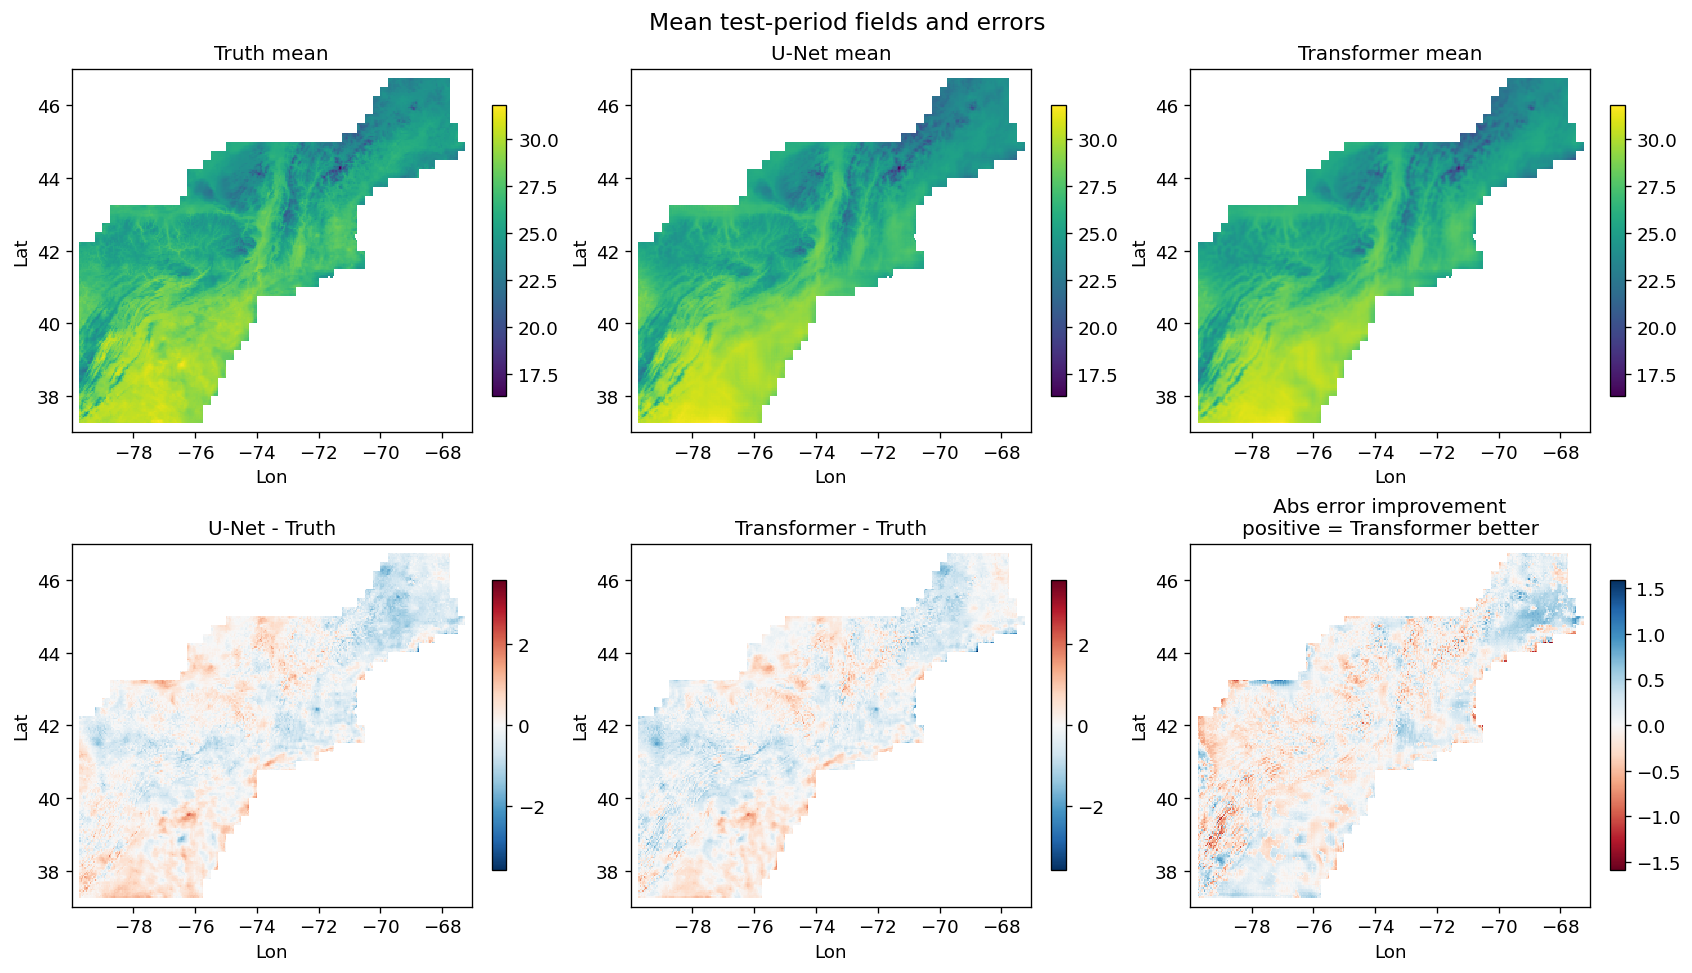

In [18]:
# Mean prediction and error composites over all test days
truth_mean = truth.where(mask).mean(dim="time")
interp_mean = interp.where(mask).mean(dim="time")
unet_mean = unet.where(mask).mean(dim="time")
tf_mean = tf.where(mask).mean(dim="time")

unet_err = unet_mean - truth_mean
tf_err = tf_mean - truth_mean
tf_vs_unet_abs_improve = np.abs(unet_err) - np.abs(tf_err)

field_vmin = np.nanmin([truth_mean.values, unet_mean.values, tf_mean.values])
field_vmax = np.nanmax([truth_mean.values, unet_mean.values, tf_mean.values])
err_max = np.nanmax(np.abs([unet_err.values, tf_err.values]))
imp_max = np.nanmax(np.abs(tf_vs_unet_abs_improve.values))

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

panels = [
    (truth_mean, "Truth mean", "viridis", field_vmin, field_vmax),
    (unet_mean, "U-Net mean", "viridis", field_vmin, field_vmax),
    (tf_mean, "Transformer mean", "viridis", field_vmin, field_vmax),
    (unet_err, "U-Net - Truth", "RdBu_r", -err_max, err_max),
    (tf_err, "Transformer - Truth", "RdBu_r", -err_max, err_max),
    (tf_vs_unet_abs_improve, "Abs error improvement\npositive = Transformer better", "RdBu", -imp_max, imp_max),
]

for ax, (da, title, cmap, vmin, vmax) in zip(axes.flat, panels):
    pcm = ax.pcolormesh(
        da["lon"], da["lat"], da.where(mask).values,
        shading="auto", cmap=cmap, vmin=vmin, vmax=vmax
    )
    ax.set_title(title)
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")
    plt.colorbar(pcm, ax=ax, shrink=0.8)

fig.suptitle("Mean test-period fields and errors", fontsize=14)
#plt.savefig(fig_dir / "mean_field_error_comparison.png", bbox_inches="tight", dpi=300)
plt.show()


In [12]:
# Pick example days: Transformer better, U-Net better, hottest truth day
rmse_diff = daily["U-Net T+Elev RMSE"] - daily["Transformer T+Elev RMSE"]
tf_best_day = rmse_diff.idxmax()
unet_best_day = rmse_diff.idxmin()

truth_daily_mean = truth.where(mask).mean(dim=("lat", "lon"), skipna=True).to_pandas()
hottest_day = truth_daily_mean.idxmax()

print("Transformer most better than U-Net:", tf_best_day)
print("U-Net most better than Transformer:", unet_best_day)
print("Hottest truth day:", hottest_day)


Transformer most better than U-Net: 2023-08-02 00:00:00
U-Net most better than Transformer: 2025-06-28 00:00:00
Hottest truth day: 2025-06-24 00:00:00


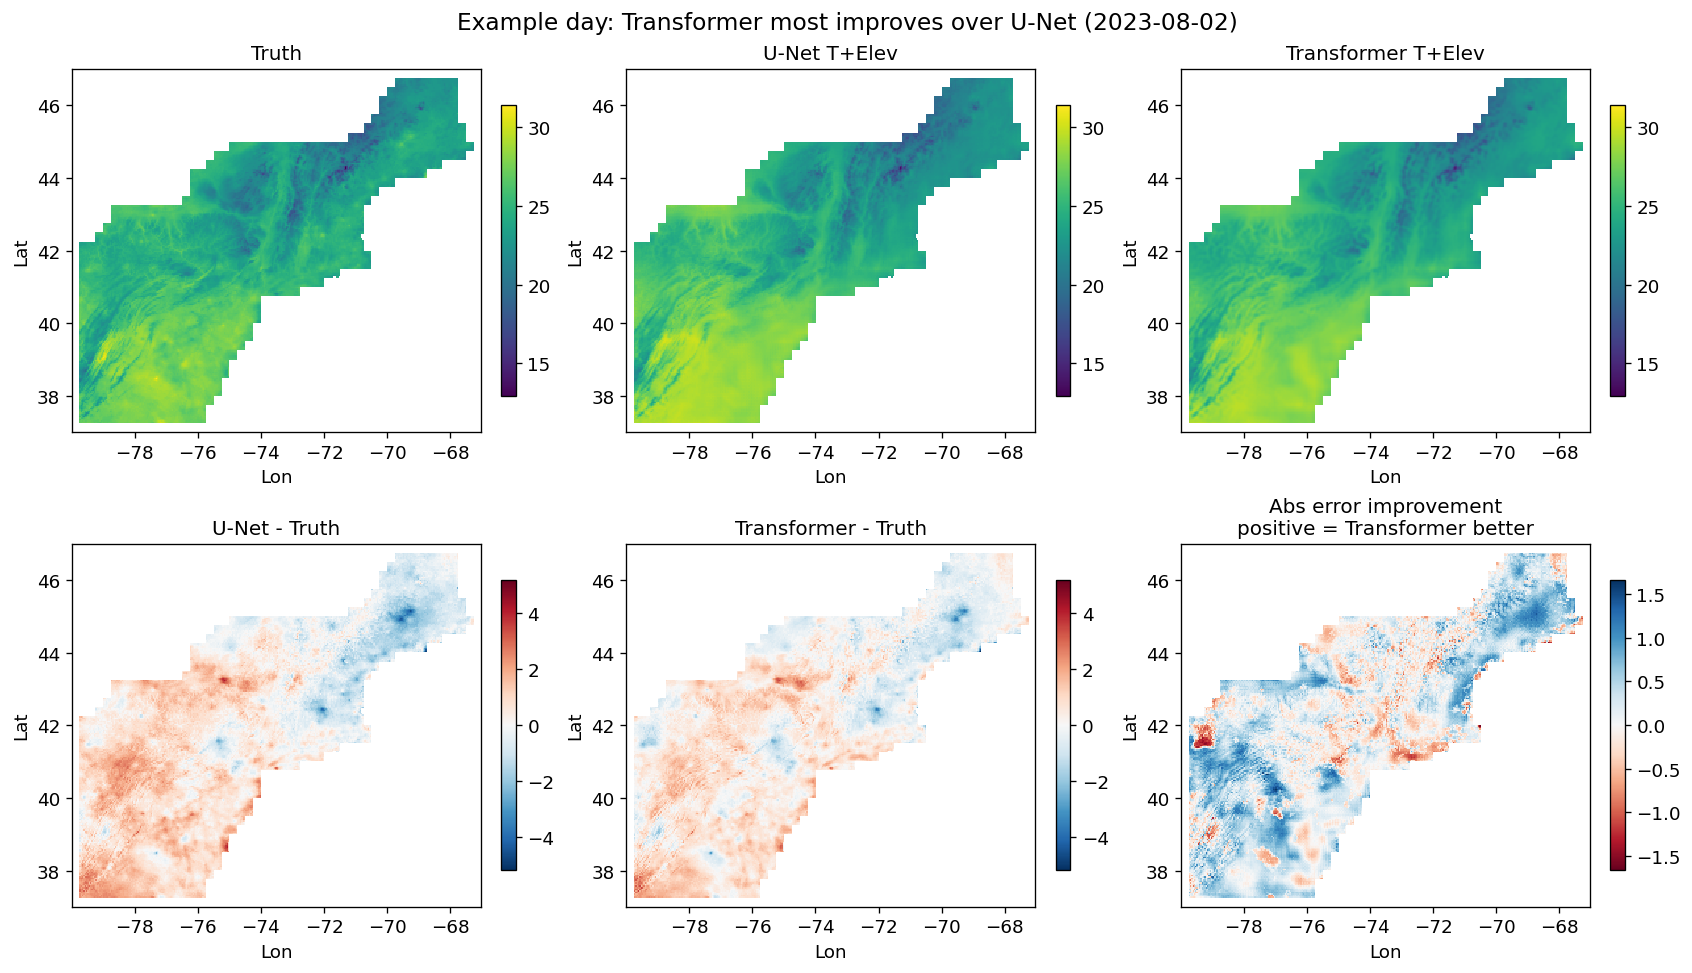

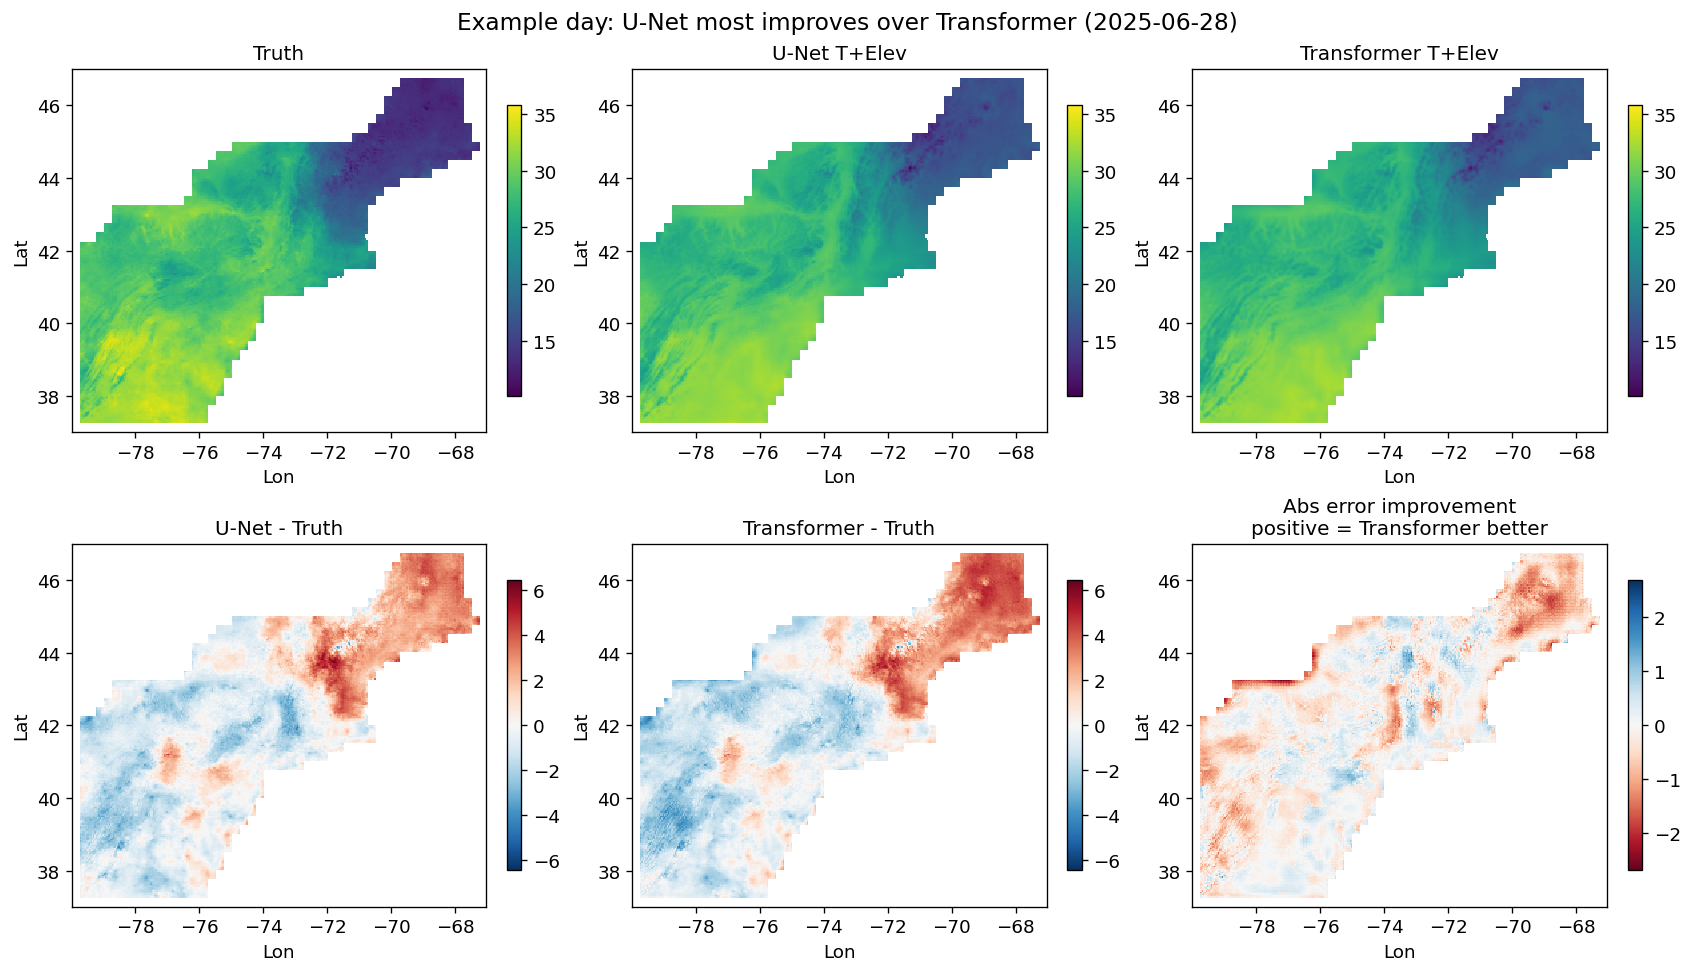

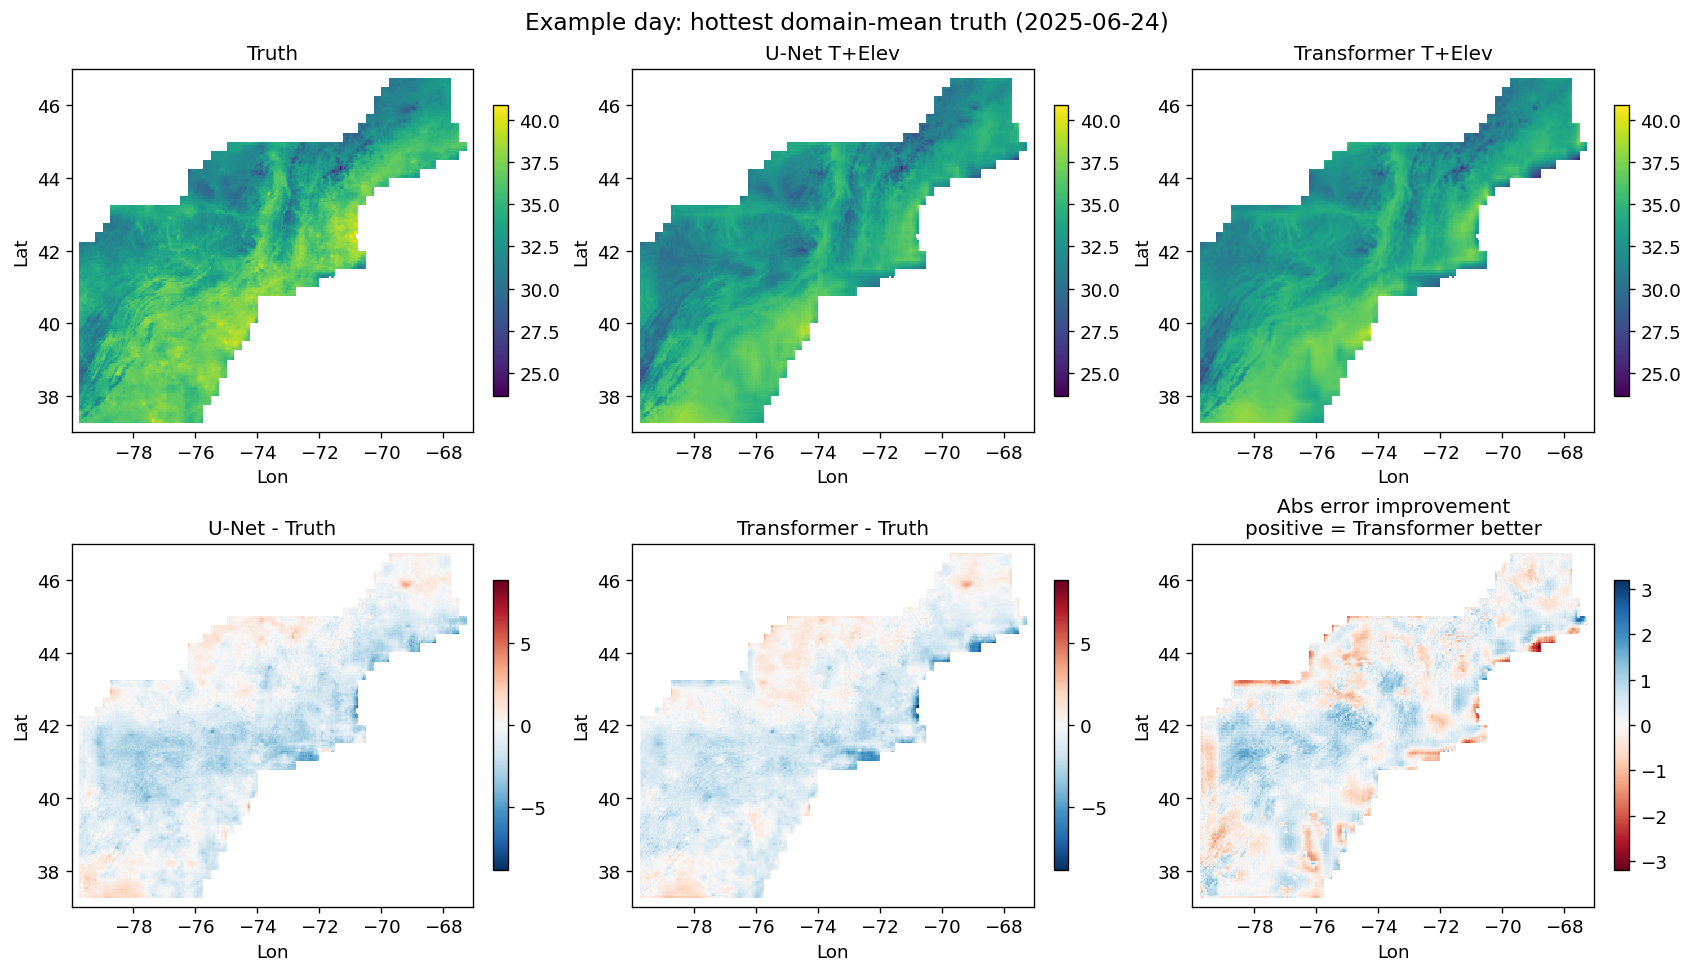

In [22]:
def plot_day(date, title):
    date = np.datetime64(date)
    t = truth.sel(time=date)
    u = unet.sel(time=date)
    f = tf.sel(time=date)

    u_err = u - t
    f_err = f - t
    improve = np.abs(u_err) - np.abs(f_err)

    field_vmin = np.nanmin([t.where(mask).values, u.where(mask).values, f.where(mask).values])
    field_vmax = np.nanmax([t.where(mask).values, u.where(mask).values, f.where(mask).values])
    err_max = np.nanmax(np.abs([u_err.where(mask).values, f_err.where(mask).values]))
    imp_max = np.nanmax(np.abs(improve.where(mask).values))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

    panels = [
        (t, "Truth", "viridis", field_vmin, field_vmax),
        (u, "U-Net T+Elev", "viridis", field_vmin, field_vmax),
        (f, "Transformer T+Elev", "viridis", field_vmin, field_vmax),
        (u_err, "U-Net - Truth", "RdBu_r", -err_max, err_max),
        (f_err, "Transformer - Truth", "RdBu_r", -err_max, err_max),
        (improve, "Abs error improvement\npositive = Transformer better", "RdBu", -imp_max, imp_max),
    ]

    for ax, (da, panel_title, cmap, vmin, vmax) in zip(axes.flat, panels):
        pcm = ax.pcolormesh(
            da["lon"], da["lat"], da.where(mask).values,
            shading="auto", cmap=cmap, vmin=vmin, vmax=vmax
        )
        ax.set_title(panel_title)
        ax.set_xlabel("Lon")
        ax.set_ylabel("Lat")
        plt.colorbar(pcm, ax=ax, shrink=0.8)

    fig.suptitle(title, fontsize=14)
    return fig

for date, label in [
    (tf_best_day, "Example day: Transformer most improves over U-Net"),
    (unet_best_day, "Example day: U-Net most improves over Transformer"),
    (hottest_day, "Example day: hottest domain-mean truth"),
]:
    fig = plot_day(date, f"{label} ({pd.to_datetime(date).date()})")
    out = label.lower().replace(" ", "_").replace(":", "").replace("-", "_")
    plt.savefig(fig_dir / f"{out}.png", bbox_inches="tight", dpi=300)
    plt.show()


In [14]:
# Save metric tables for your paper/poster
summary.to_csv(fig_dir / "overall_metrics.csv")
daily.to_csv(fig_dir / "daily_metrics.csv")
daily_summary.to_csv(fig_dir / "daily_metric_summary.csv")

summary


,MSE,RMSE,MAE,Bias,Overall correlation,RMSE improvement vs interp (%),MAE improvement vs interp (%)
Interpolation,2.461787,1.569008,1.193424,-0.513263,0.941367,0.000000,0.000000
U-Net T+Elev,1.368507,1.169832,0.902376,-0.078094,0.963428,25.441302,24.387611
Transformer T+Elev,1.333456,1.154754,0.884036,-0.120808,0.965489,26.402318,25.924365
